In [1]:
import pandas as pd
import numpy as np

import glob
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
basepath = ""

# Coverage distribution

In [32]:
def plot_coverage(sample, arr_cov, window=100, bins=10000, lower_percentile=15, upper_percentile=85):
    plt.hist(arr_cov, bins=bins, color='skyblue', edgecolor='black')
    plt.xlim(0,20)

    q_lower = np.percentile(arr_cov, lower_percentile)
    q_upper = np.percentile(arr_cov, upper_percentile)
    plt.axvline(q_lower, color='red', linestyle='dashed', label=f'15th percentile ({q_lower:.2f})')
    plt.axvline(q_upper, color='green', linestyle='dashed', label=f'75th percentile ({q_upper:.2f})')

    plt.xlabel('Coverage')
    plt.ylabel('Frequency')
    plt.title(f'{sample}. Coverage distribution in {window}bp windows, bins={bins}')

    plt.show()


In [ ]:
def analyze_coverage_in_windows(sample="8208", window=100, bins=10000, lower_percentile=15, upper_percentile=85):
    cov_regions=f'{basepath}/Coverage/w{window}_coverage/{sample}_merged_duprm_realigned.CM019820.2.q20.F3844.w{window}.regions.Y.bed'
    df = pd.read_csv(cov_regions, sep='\t', header=None, names=['chrom', 'start', 'end', 'coverage'])
    print("Mean:   ", df["coverage"].mean())
    print("Median: ", df["coverage"].median())
    plot_coverage(sample, df['coverage'], window=window, bins=bins, 
                  lower_percentile=lower_percentile, upper_percentile=upper_percentile)

Mean:    17.7721093162093
Median:  3.52


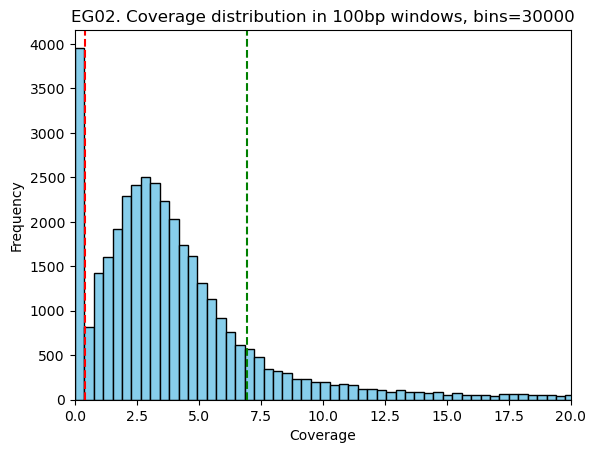

In [34]:
analyze_coverage_in_windows(sample='EG02', window=100, bins=30000, lower_percentile=10, upper_percentile=80)

Mean:    13.710602769277076
Median:  3.02


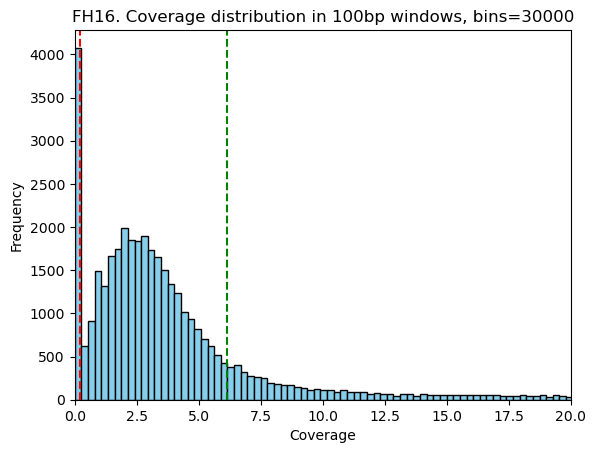

In [35]:
analyze_coverage_in_windows(sample='FH16', window=100, bins=30000, lower_percentile=10, upper_percentile=80)

In [ ]:
cov_perbase=f"{basepath}/Coverage/8208_merged_duprm_realigned.CM019820.2.q20.F3844.per-base.Y.bed"
df = pd.read_csv(cov_perbase, sep='\t', header=None, names=['chrom', 'start', 'end', 'coverage'])
print("Mean:   ", df["coverage"].mean())
print("Median: ", df["coverage"].median())

Mean:    87.2622810928362
Median:  12.0


# Proportion of postions with certain coverage

In [ ]:
covs=[50, 100, 250, 1000, 2000, 5000, 10000]
df_cov=pd.DataFrame(columns=['Mean', 'Median', "Max", "Min", "5%", "95%"])
high_cov_regions = pd.DataFrame(columns=["Species"]+[f'prop_{cov}x_Yregions' for cov in covs])

for sp in ["GSL", "SSL"]:

    for file in glob.glob(f"{basepath}/Coverage/{sp}_CM019820.2_win1/*.mean.regions.bed.gz"):
        sample = os.path.basename(file).split(".")[0]
        df = pd.read_csv(file, sep='\t', header=None, names=['chrom', 'start', 'end', 'mean_cov'])
        num_regions = len(df)
        high_cov_regions.loc[sample] = [sp] + [len(df[df["mean_cov"] > cov])/num_regions for cov in covs]

high_cov_regions

,Species,prop_50x_Yregions,prop_100x_Yregions,prop_250x_Yregions,prop_1000x_Yregions,prop_2000x_Yregions,prop_5000x_Yregions,prop_10000x_Yregions
GE05,GSL,0.011813,0.002229,0.001730,0.001275,0.001099,0.000028,0.00000
PC02,GSL,0.018830,0.005140,0.001888,0.001446,0.001254,0.000985,0.00000
GE07,GSL,0.012265,0.002382,0.001954,0.001459,0.001264,0.001009,0.00000
PC25,GSL,0.014666,0.003687,0.001821,0.001392,0.001220,0.000817,0.00000
IV01,GSL,0.025733,0.008705,0.002002,0.001560,0.001334,0.001083,0.00046
...,...,...,...,...,...,...,...,...
N411,SSL,0.032168,0.009419,0.002632,0.001293,0.000946,0.000000,0.00000
F4,SSL,0.030286,0.009465,0.003110,0.001442,0.001110,0.000091,0.00000
H1_1_98,SSL,0.043051,0.020351,0.004895,0.001678,0.001309,0.000858,0.00000
SSL53,SSL,0.032175,0.011217,0.003203,0.001586,0.001244,0.000779,0.00000


In [40]:
for colname in high_cov_regions.columns[1:]:
    for sp in ["GSL", "SSL"]:
        high_cov_regions_sp = high_cov_regions[high_cov_regions["Species"] == sp]
        df_cov.loc[f"{sp}_{colname}"] = [
            high_cov_regions_sp[colname].mean().round(5)*100,
            high_cov_regions_sp[colname].median()*100,
            high_cov_regions_sp[colname].max()*100,
            high_cov_regions_sp[colname].min()*100,
            high_cov_regions_sp[colname].quantile(0.05).round(5)*100,
            high_cov_regions_sp[colname].quantile(0.95).round(5)*100
        ]
df_cov

,Mean,Median,Max,Min,5%,95%
GSL_prop_50x_Yregions,2.238,1.922029,4.969462,0.836158,1.225,3.639
SSL_prop_50x_Yregions,3.355,3.457209,4.346922,1.161300,1.743,4.316
GSL_prop_100x_Yregions,0.672,0.658436,1.249044,0.222949,0.242,1.059
SSL_prop_100x_Yregions,1.175,1.089885,2.035134,0.477478,0.688,1.726
GSL_prop_250x_Yregions,0.199,0.199771,0.220766,0.172956,0.184,0.214
SSL_prop_250x_Yregions,0.319,0.309941,0.530506,0.199520,0.207,0.489
GSL_prop_1000x_Yregions,0.153,0.154268,0.170623,0.127478,0.139,0.164
SSL_prop_1000x_Yregions,0.153,0.153616,0.168491,0.129259,0.133,0.168
GSL_prop_2000x_Yregions,0.132,0.130614,0.146693,0.109919,0.122,0.144
SSL_prop_2000x_Yregions,0.120,0.120931,0.138239,0.094643,0.097,0.136


In [ ]:
PALETTE_COLORBLIND = ["#000000", "#D55E00", "#009E73", "#CC79A7",
                      "#F0E442", "#56B4E9", "#E69F00", "#0072B2"]

def plot_coverage_on_ax(ax, path, max_coverage=100, ylabel="Frequency", max_freq=0.00001):
    palette = sns.color_palette("muted").as_hex()[::-1] #PALETTE_COLORBLIND
    
    files = glob.glob(path)
    labels = [os.path.basename(f).split(".")[0] for f in files]
    
    for file, label, color in zip(files, labels, palette):
        cov = pd.read_csv(
            file,
            sep="\t",
            header=None,
            usecols=[3],
            names=["coverage"],
            compression="gzip"
        )["coverage"]
        
        counts = cov.value_counts().sort_index()
        freq = counts / counts.sum()
        
        ax.plot(freq.index, freq.values, color=color, label=label, linewidth=1)

    ax.set(
        xlabel="Coverage",
        ylabel=ylabel,
        xlim=(0, max_coverage),
        ylim=(0, max_freq)
    )

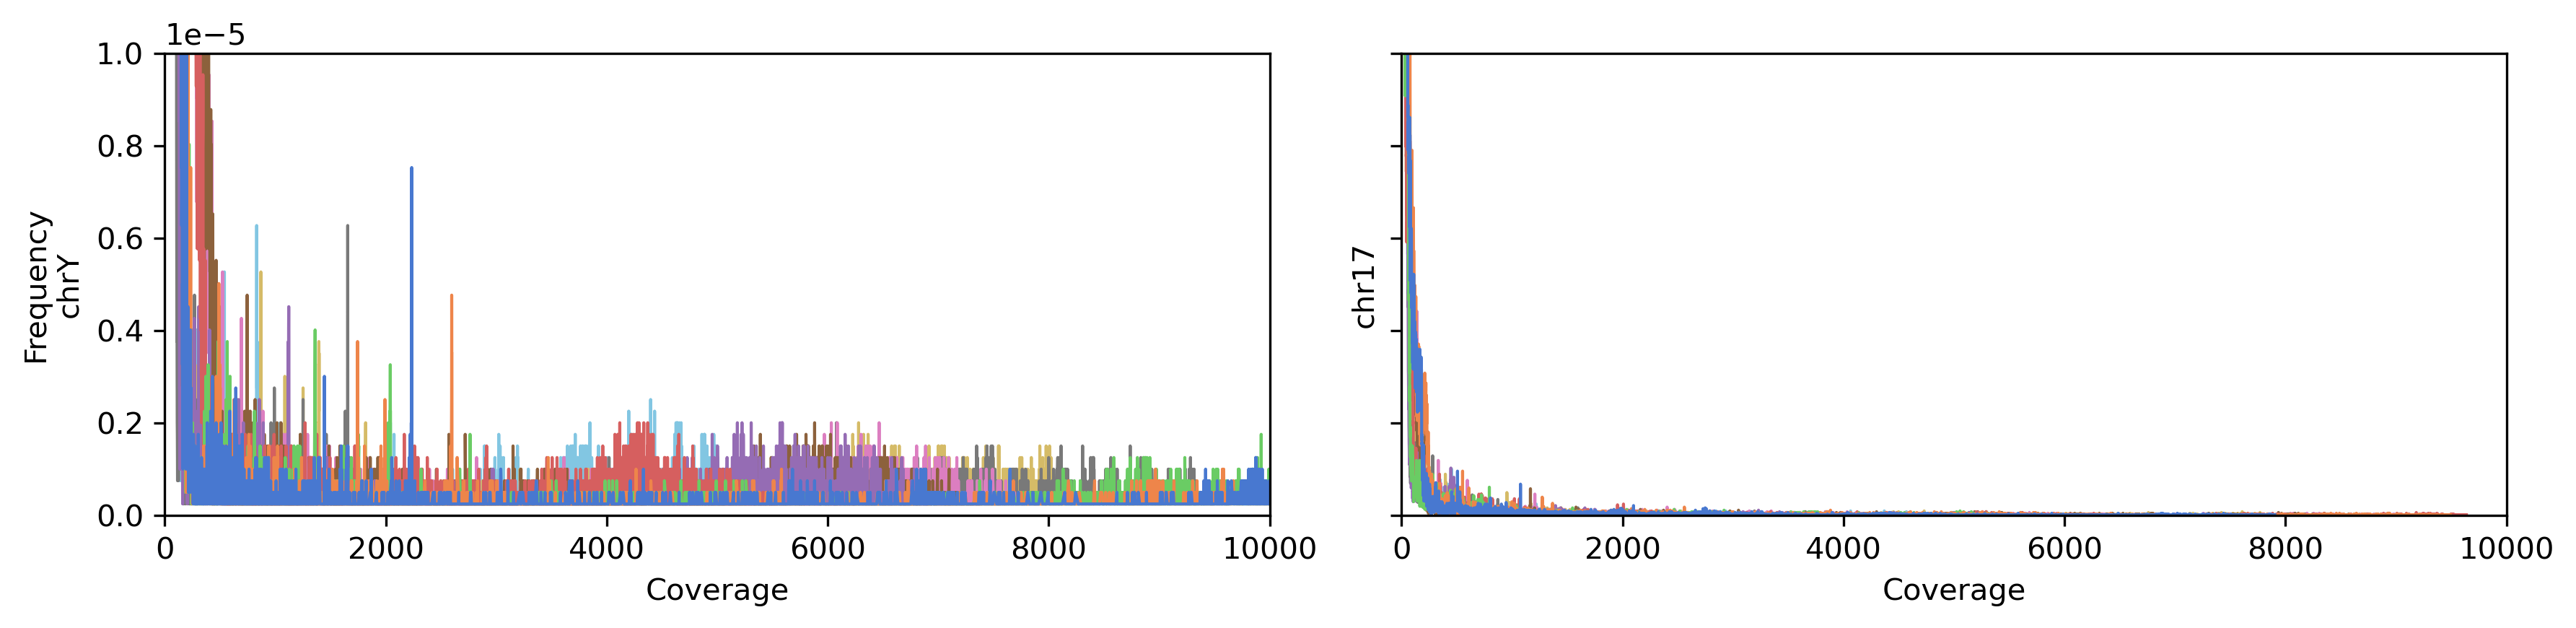

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=300, sharey=True)

base=f"{basepath}/Coverage"
# chrY
plot_coverage_on_ax(
    axes[0],
    path=f'{base}/ALL_CM019820.2_win1/*.mean.regions.bed.gz',
    max_coverage=10000,
    ylabel="Frequency\nchrY"
)

# chr17
plot_coverage_on_ax(
    axes[1],
    path=f'{base}/ALL_CM019818.2_win1/*.mean.regions.bed.gz',
    max_coverage=10000,
    ylabel="chr17"
)


fig.tight_layout()
plt.show()

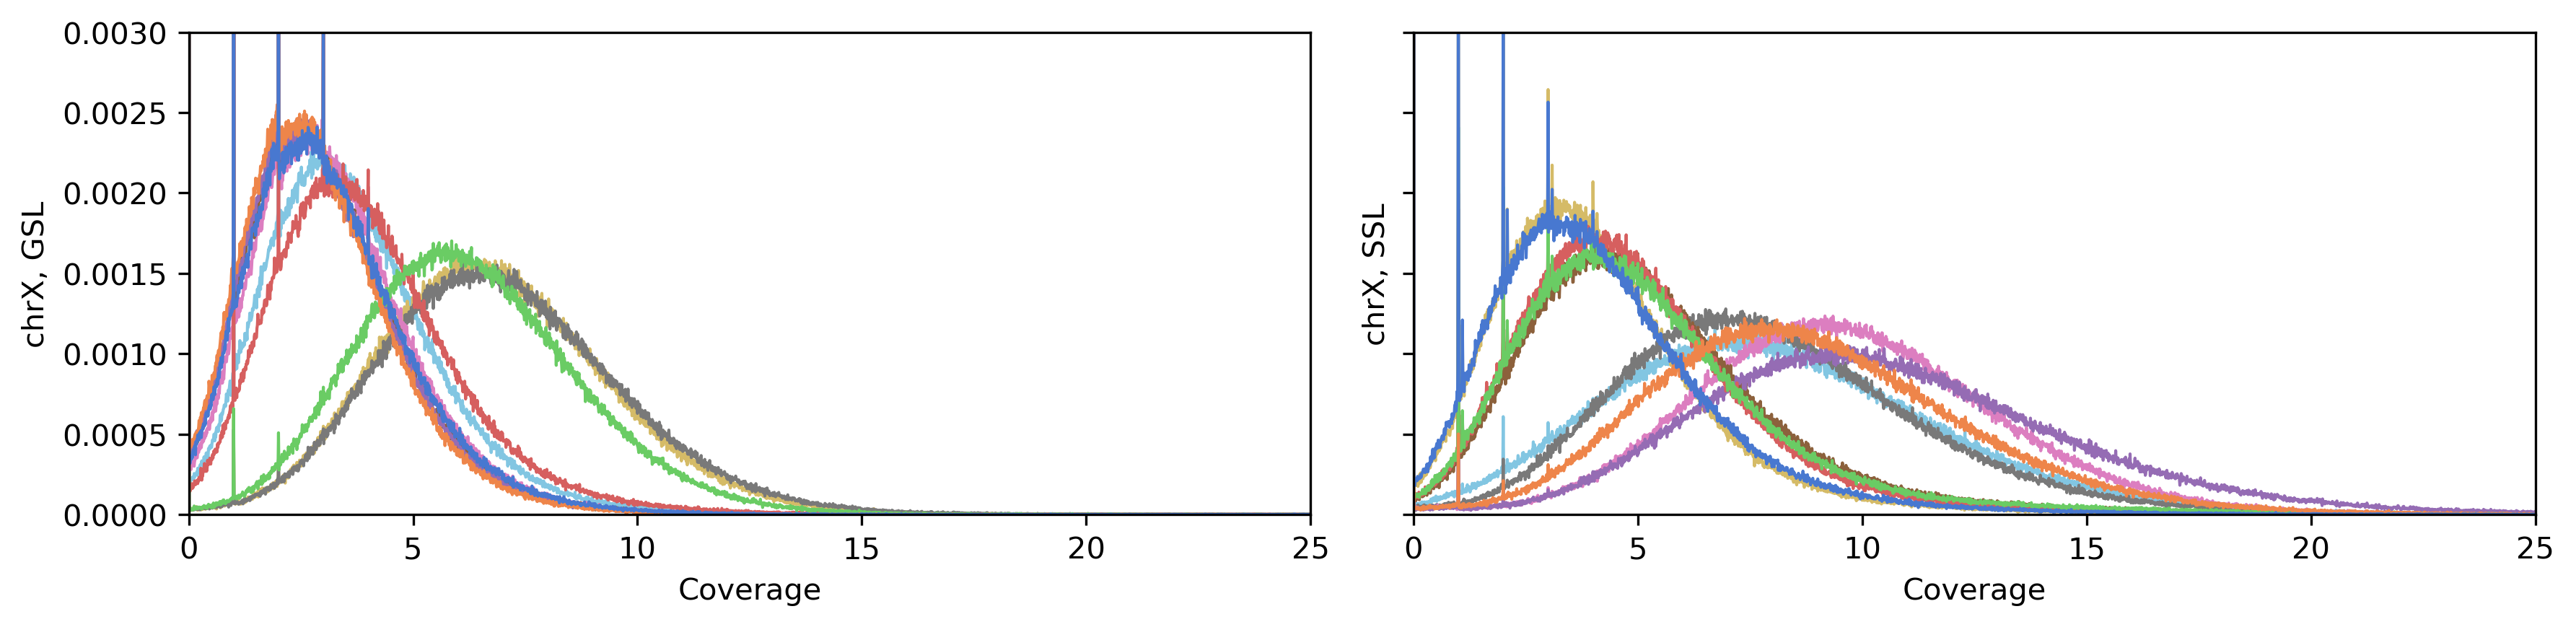

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=300, sharey=True)

base=f"{basepath}/Coverage"

# chrX
plot_coverage_on_ax(
    axes[0],
    path=f'{base}/GSL_CM019819.2_win100/*.mean.regions.bed.gz',
    max_coverage=25,
    max_freq=0.003,
    ylabel="chrX, GSL"
)
# chrX
plot_coverage_on_ax(
    axes[1],
    path=f'{base}/SSL_CM019819.2_win100/*.mean.regions.bed.gz',
    max_coverage=25,
    max_freq=0.003,
    ylabel="chrX, SSL"
)

fig.tight_layout()
plt.show()

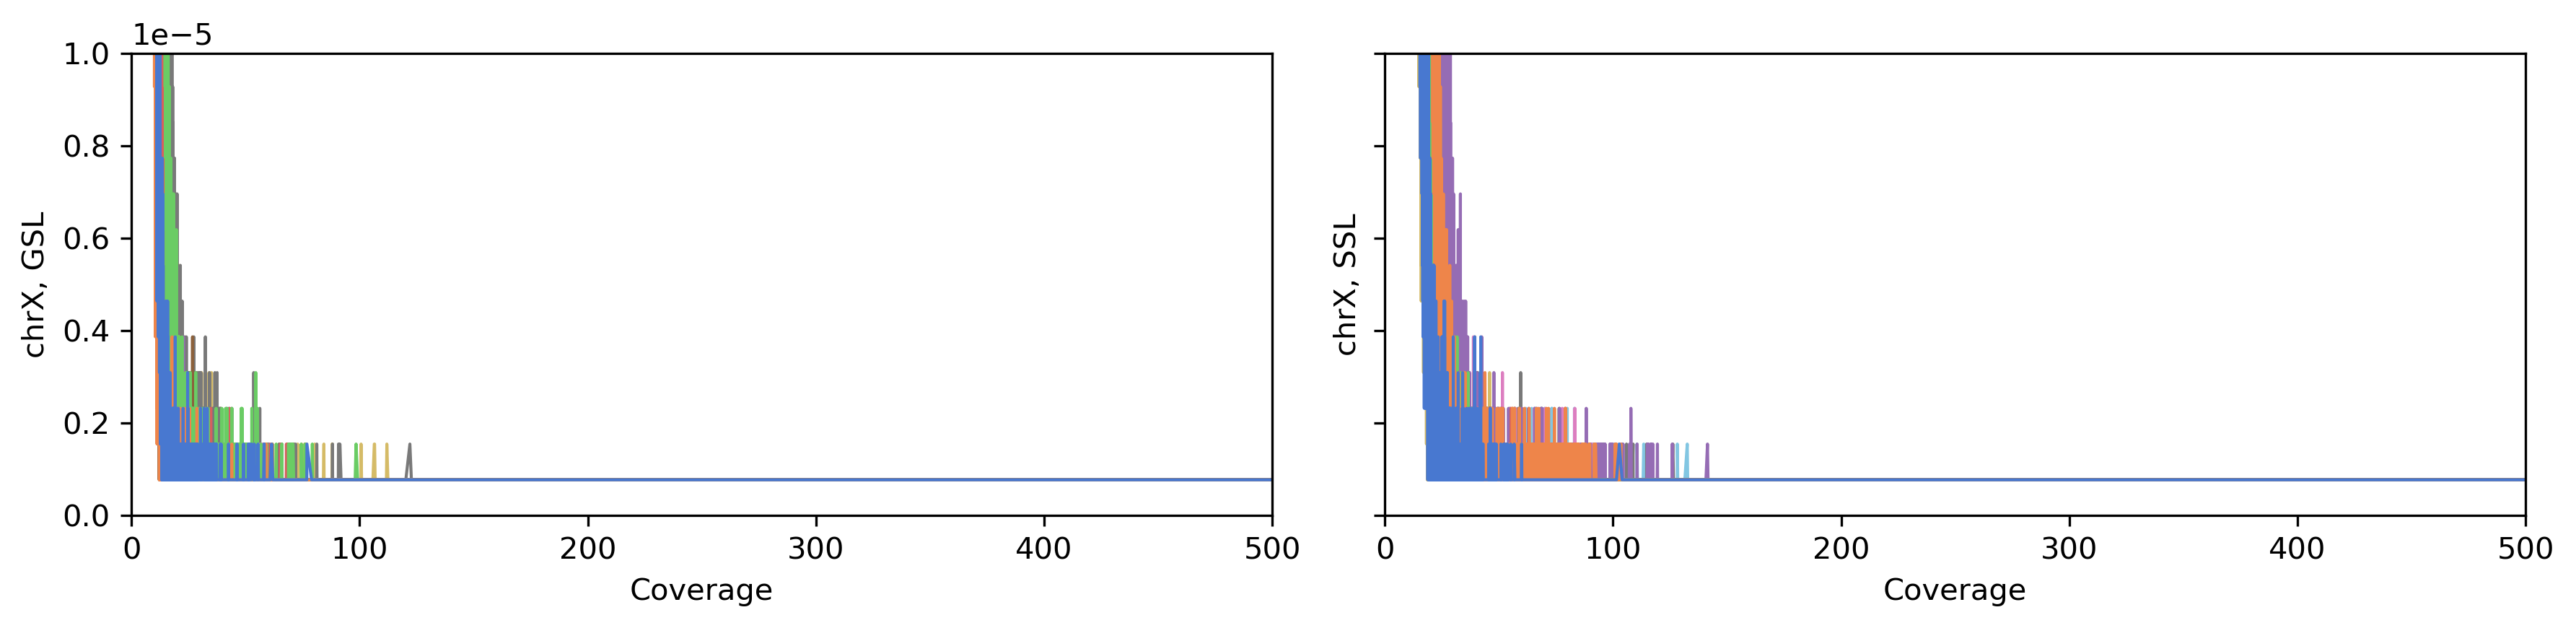

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=300, sharey=True)

base=f"{basepath}/Coverage"

# chrX
plot_coverage_on_ax(
    axes[0],
    path=f'{base}/GSL_CM019819.2_win100/*.mean.regions.bed.gz',
    max_coverage=500,
    max_freq=0.00001,
    ylabel="chrX, GSL"
)
# chrX
plot_coverage_on_ax(
    axes[1],
    path=f'{base}/SSL_CM019819.2_win100/*.mean.regions.bed.gz',
    max_coverage=500,
    max_freq=0.00001,
    ylabel="chrX, SSL"
)

fig.tight_layout()
plt.show()

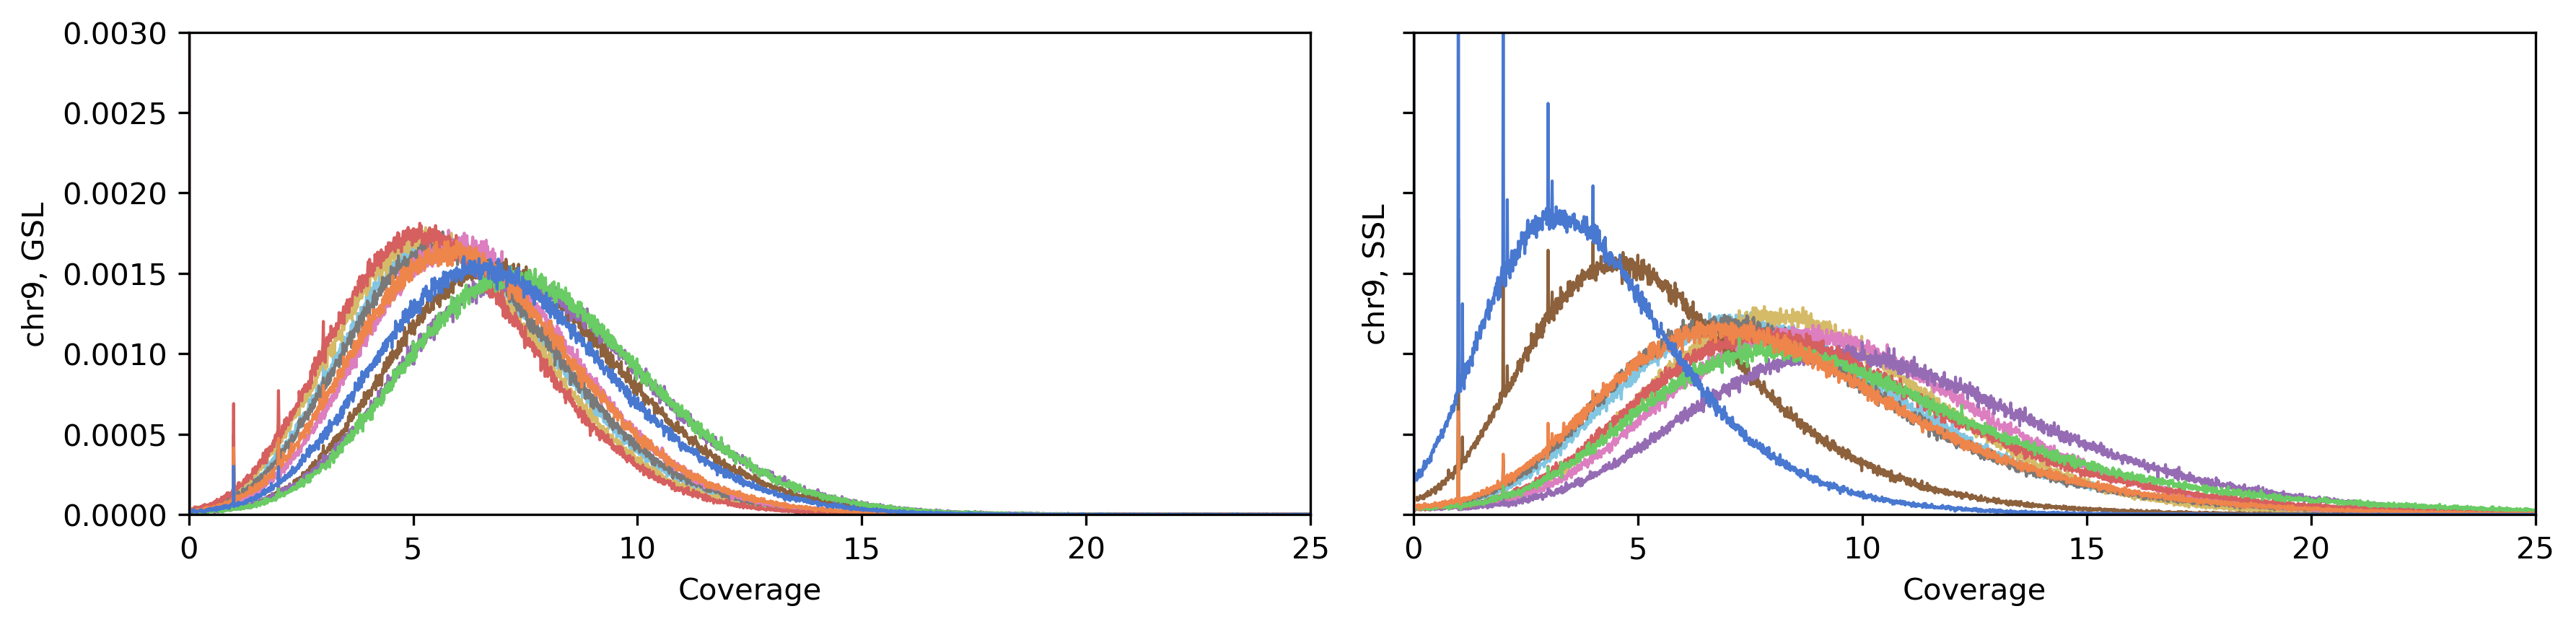

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=300, sharey=True)

base=f"{basepath}/Coverage"

# chr9
plot_coverage_on_ax(
    axes[0],
    path=f'{base}/GSL_CM019810.2_win100/*.mean.regions.bed.gz',
    max_coverage=25,
    max_freq=0.003,
    ylabel="chr9, GSL"
)
# chr9
plot_coverage_on_ax(
    axes[1],
    path=f'{base}/SSL_CM019810.2_win100/*.mean.regions.bed.gz',
    max_coverage=25,
    max_freq=0.003,
    ylabel="chr9, SSL"
)

fig.tight_layout()
plt.show()

# Coverage statistics

In [ ]:
window_size=100
for sp in ['GSL', 'SSL']:
    for chr in ['CM019810.2', 'CM019819.2', 'CM019820.2', 'CM019821.1']:
        path=f"{basepath}/Coverage/{sp}_{chr}_win{window_size}/*.regions.bed.gz"
        df_cov=pd.DataFrame(columns=['Sample', 'Mean', 'Median', "Max", "Min", "5%", "10%", "15%", "80%", "85%", "90%", "95%"])
        for bed in glob.glob(path):
            df = pd.read_csv(bed, sep='\t', header=None, names=['chrom', 'start', 'end', 'coverage'])
            sample = os.path.basename(bed).split('.')[0]
            df_cov.loc[sample] = [sample,
                                df["coverage"].mean().round(2),
                                df["coverage"].median(),
                                df["coverage"].max(),
                                df["coverage"].min(),
                                df["coverage"].quantile(0.05).round(2),
                                df["coverage"].quantile(0.10).round(2),
                                df["coverage"].quantile(0.15).round(2),
                                df["coverage"].quantile(0.80).round(2),
                                df["coverage"].quantile(0.85).round(2),
                                df["coverage"].quantile(0.90).round(2),
                                df["coverage"].quantile(0.95).round(2)]
        df_cov.to_csv(f"{basepath}/Coverage/stats/{sp}_{chr}_win{window_size}.stats.csv", 
                    sep='\t',
                    index=False)



In [ ]:

for sp in ['GSL', 'SSL']:
      for chr in ['CM019810.2', 'CM019819.2', 'CM019820.2', 'CM019821.1']:
            df = pd.read_csv(f"{basepath}/Coverage/stats/{sp}_{chr}_win100.stats.csv",
                        sep='\t')
            print(sp, chr, ": Mean=", df["Mean"].mean().__round__(2), 
                  "+/-", df["Mean"].std().__round__(2), 
                  "; Median=", df["Median"].mean().__round__(2), 
                  "+/-", df["Median"].std().__round__(2),
                  "; 85%=", df["85%"].mean().__round__(2))

GSL CM019810.2 : Mean= 7.11 +/- 1.14 ; Median= 6.69 +/- 1.11 ; 85%= 9.53
GSL CM019819.2 : Mean= 4.45 +/- 1.67 ; Median= 4.25 +/- 1.72 ; 85%= 6.61
GSL CM019820.2 : Mean= 18.5 +/- 3.79 ; Median= 3.52 +/- 0.49 ; 85%= 9.06
GSL CM019821.1 : Mean= 614.31 +/- 298.87 ; Median= 611.79 +/- 297.82 ; 85%= 687.54
SSL CM019810.2 : Mean= 9.08 +/- 1.7 ; Median= 8.56 +/- 1.66 ; 85%= 12.73
SSL CM019819.2 : Mean= 5.73 +/- 2.4 ; Median= 5.36 +/- 2.47 ; 85%= 8.5
SSL CM019820.2 : Mean= 14.99 +/- 2.85 ; Median= 3.84 +/- 0.78 ; 85%= 11.07
SSL CM019821.1 : Mean= 1121.6 +/- 442.89 ; Median= 1163.36 +/- 463.82 ; 85%= 1298.75


# Coverage distribution for all samples (violin/box plot)

In [2]:
def sample_name_from_path(fp):
    fname = os.path.basename(fp)
    return fname.split(".", 1)[0]

def plot_coverage_violins(bed_dir, coverage_col_idx=3, 
                          sample_name_func=sample_name_from_path, 
                          figsize=(20,6), ylim=10, style='boxplot'):
    pattern = os.path.join(bed_dir, "*.bed")
    files = glob.glob(pattern)
    
    dfs = []
    for f in files:
        if sample_name_func:
            sample = sample_name_func(f)
        else:
            sample = os.path.splitext(os.path.basename(f))[0]
        
        df = pd.read_csv(f,
                         sep="\t",
                         header=None,
                         usecols=[coverage_col_idx],
                         names=["coverage"])
        df["sample"] = sample
        dfs.append(df)
    
    all_df = pd.concat(dfs, ignore_index=True).sort_values("sample")
    
    plt.figure(figsize=figsize)
    # sns.set_style("whitegrid")
    if style == 'violinplot':
        ax = sns.violinplot(x="sample", y="coverage", data=all_df,
                            cut=0,
                            inner="quartile",
                            density_norm="width",
                            palette="muted",
                            hue="sample",
                            legend=False)
    else:
        ax = sns.boxplot(x="sample", y="coverage", data=all_df,
                            palette="muted",
                            hue="sample",
                            legend=False)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("Coverage", fontsize=18)
    ax.tick_params(axis='x', labelrotation=90, labelsize=14)
    # ax.set_title("Coverage distribution per sample", fontsize=12)
    ax.set_ylim(0, ylim)
    plt.tight_layout()
    plt.show()



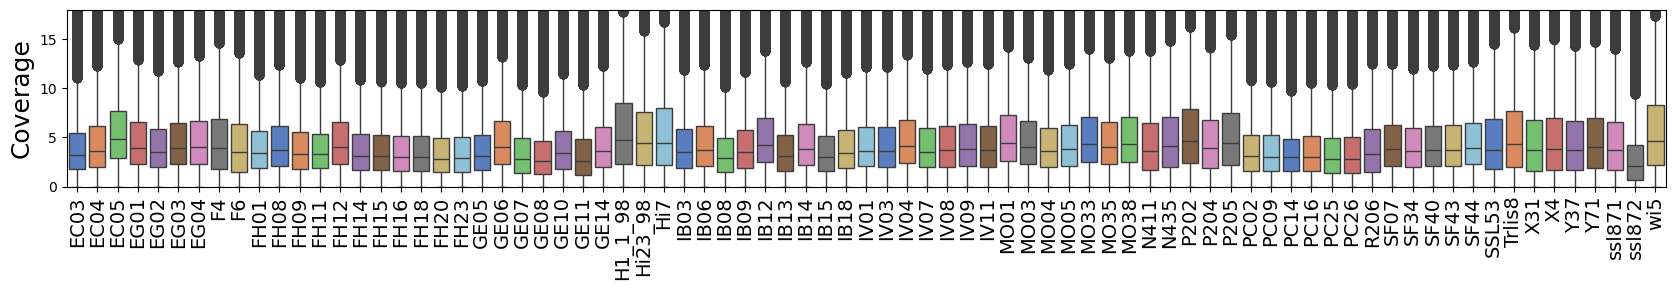

In [ ]:
plot_coverage_violins(f"{basepath}/Coverage/CM019820.2_win100",
                      figsize=(17,3), ylim=18, style='boxplot')

# Coverage distribution by the length of the chromosome

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_coverage_profile(bed_file,
                          figsize=(10, 4),
                          line_color='black',
                          x_unit='Mb',
                          ylim=None):

    df = pd.read_csv(
        bed_file,
        sep='\t',
        header=None,
        usecols=[1, 2, 3],
        names=['start', 'end', 'coverage']
    )

    df['mid'] = (df['start'] + df['end']) / 2

    if x_unit == 'Mb':
        x = df['mid'] / 1e6
        xlabel = 'Position (Mb)'
    else:
        x = df['mid']
        xlabel = 'Position (bp)'

    plt.figure(figsize=figsize)
    plt.plot(
        x,
        df['coverage'],
        color=line_color,
        linewidth=1
    )
    plt.xlabel(xlabel)
    plt.ylabel('Coverage')
    plt.title('Coverage Profile')
    plt.grid(linestyle='', alpha=0.4)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.tight_layout()
    plt.show()


X chromosome

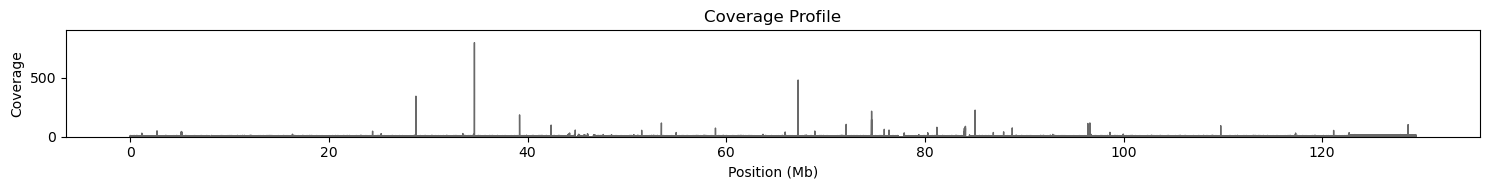

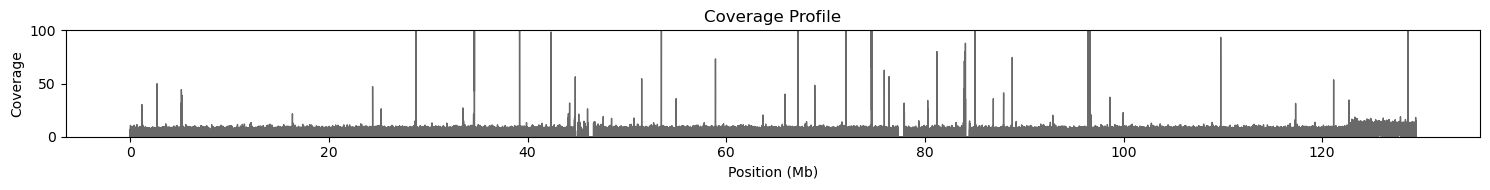

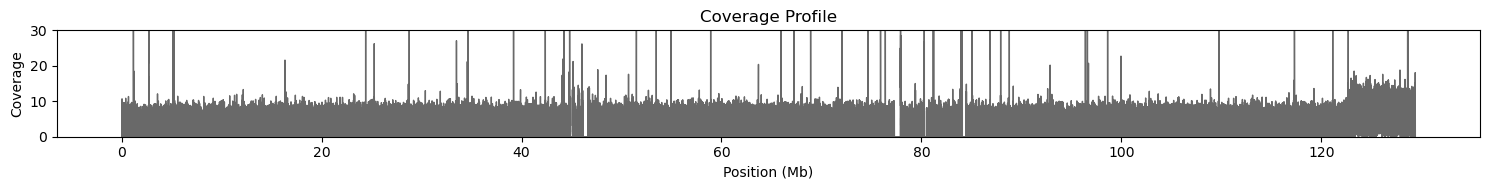

In [ ]:
coverage_bed=f"{basepath}/Coverage/GSL_CM019819.2_win100/FH01.REA.MD.CM019819.2.Q20.F3844.bam.win100.mean.regions.bed.gz"
for limit in [(0, 900), (0, 100), (0, 30)]:
    plot_coverage_profile(
        bed_file=coverage_bed,
        figsize=(15, 2),
        line_color="dimgray",
        x_unit="Mb",
        ylim=limit
    )


Y chromosome

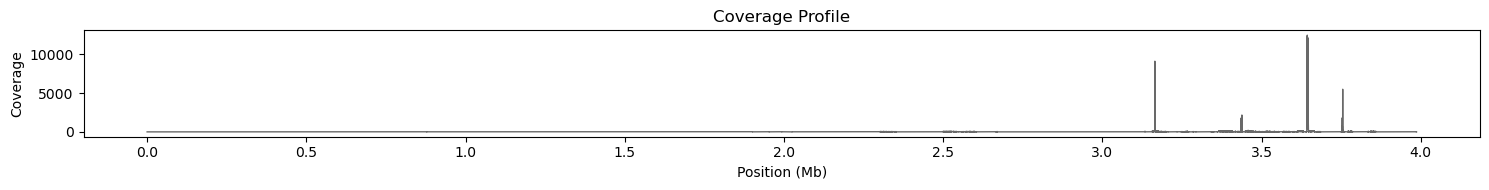

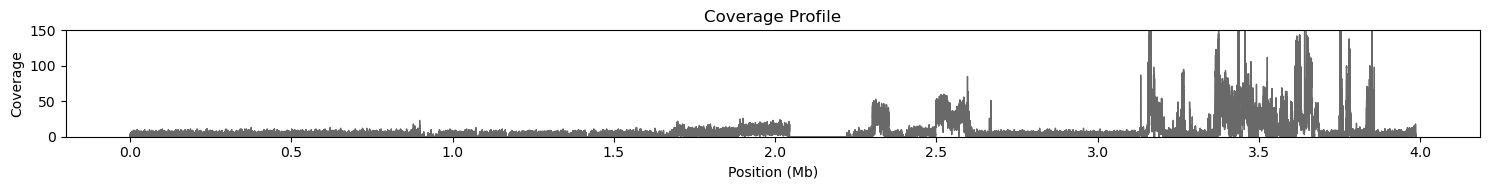

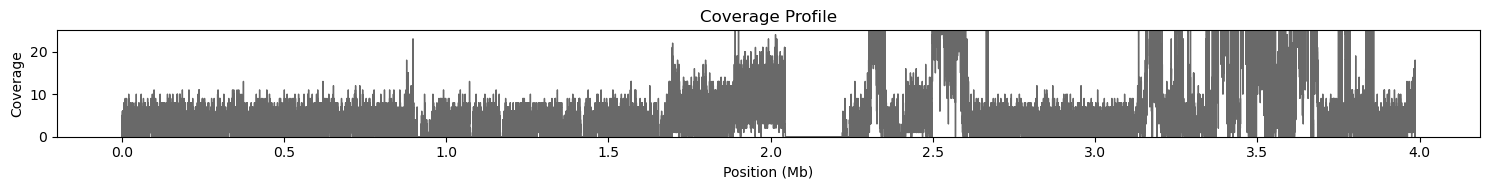

In [ ]:
coverage_bed=f"{basepath}/Coverage/GSL_CM019820.2_win1/FH01.REA.MD.CM019820.2.Q20.F3844.bam.win1.mean.regions.bed.gz"
for limit in [None, (0, 150), (0, 25)]:
    plot_coverage_profile(
        bed_file=coverage_bed,
        figsize=(15, 2),
        line_color="dimgray",
        x_unit="Mb",
        ylim=limit
    )

In [ ]:
mean_depth_distribution_file=f"{basepath}/Coverage/CM019820.2_win100.stats.csv"
pd.read_csv(mean_depth_distribution_file, header=0, sep="\t", usecols=["Sample", "85%"]).rename(columns={"Sample": "sample", "85%": "threshold"})
 

,sample,threshold
0,FH18,7.96
1,GE08,7.20
2,IB18,8.73
3,P202,12.73
4,GE14,9.26
...,...,...
89,P205,12.07
90,P204,10.89
91,SF44,10.01
92,Trlis8,12.77
